# LSTM Modeli ile Su Talebi Tahmini

Bu notebook, LSTM (Long Short-Term Memory) sinir ağını kullanarak Malatya'nın günlük su tüketim tahmini yapar.
Derin öğrenme yaklaşımı kullanarak zaman serisi verilerinden uzun dönem bağımlılıkları öğrenecektir.

## Kütüphaneleri İçe Aktarma

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
import joblib
import warnings
warnings.filterwarnings('ignore')

# GPU/CUDA ayarları
print(f"✓ TensorFlow versiyonu: {tf.__version__}")
print(f"✓ GPU uygunluğu: {tf.config.list_physical_devices('GPU')}")

# Stil ayarları
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (13, 6)
sns.set_palette('husl')

print("\n✓ Tüm kütüphaneler başarıyla yüklendi")

✓ TensorFlow versiyonu: 2.21.0
✓ GPU uygunluğu: []

✓ Tüm kütüphaneler başarıyla yüklendi


## Veri Setini Yükleme ve Hazırlama

In [2]:
# Veri setlerini yükle
try:
    df_su = pd.read_csv('malatya_gunluk_su_tuketimi_20yil.csv')
    df_yagis = pd.read_csv('malatya_gunluk_yagis_20yil.csv')
    print(f"✓ Su tüketimi veri seti: {df_su.shape}")
    print(f"✓ Yağış veri seti: {df_yagis.shape}")
except FileNotFoundError as e:
    print(f"❌ Dosya bulunamadı: {e}")
    raise

print("\nSu Tüketimi Veri Seti:")
print(df_su.head())
print(f"\nSütunlar: {df_su.columns.tolist()}")

✓ Su tüketimi veri seti: (7305, 4)
✓ Yağış veri seti: (7305, 5)

Su Tüketimi Veri Seti:
        Tarih  Ort_Sicaklik  Hafta_Sonu  Su_Tuketimi_m3
0  2004-01-01          -1.7           0           93910
1  2004-01-02          -1.2           0           96421
2  2004-01-03          -5.7           1          102581
3  2004-01-04           0.9           1          103912
4  2004-01-05          -3.6           0           95013

Sütunlar: ['Tarih', 'Ort_Sicaklik', 'Hafta_Sonu', 'Su_Tuketimi_m3']


## Veri Temizleme ve Hazırlama

In [3]:
# Tarih sütununu standardlaştır
def prepare_date(df, label):
    date_cols = [c for c in df.columns if 'tarih' in c.lower() or 'date' in c.lower()]
    if len(date_cols) == 0:
        raise ValueError(f"{label} veri setinde tarih sütunu bulunamadı")
    date_col = date_cols[0]
    df = df.copy()
    df['date'] = pd.to_datetime(df[date_col], errors='coerce')
    return df

try:
    sudf = prepare_date(df_su, 'Su')
    yagisdf = prepare_date(df_yagis, 'Yağış')
    print("✓ Tarih sütunları hazırlandı")
except Exception as e:
    print(f"❌ Hata: {e}")
    raise

# Veri setlerini birleştir
try:
    common_cols = [c for c in yagisdf.columns if c != 'date' and c not in sudf.columns]
    df_merged = sudf.merge(yagisdf[['date'] + common_cols], on='date', how='inner', suffixes=('_su', '_yagis'))
    df_merged = df_merged.sort_values('date').reset_index(drop=True)
    print(f"✓ Birleşik veri seti: {df_merged.shape}")
except Exception as e:
    print(f"❌ Birleştirme hatası: {e}")
    raise

# Hedef sütunu belirle
try:
    target_col = [c for c in df_merged.columns if 'su' in c.lower() and 'tuketim' in c.lower()][0]
    print(f"✓ Hedef sütun: {target_col}")
except Exception as e:
    print(f"❌ Hedef sütun hatası: {e}")
    raise

✓ Tarih sütunları hazırlandı
✓ Birleşik veri seti: (7305, 9)
✓ Hedef sütun: Su_Tuketimi_m3


## Veri Normalleştirme

✓ Temizlik sonrası veri: (7305, 1)
✓ Veri normalleştirildi (0-1 aralığı)
  Min: 0.0000, Max: 1.0000


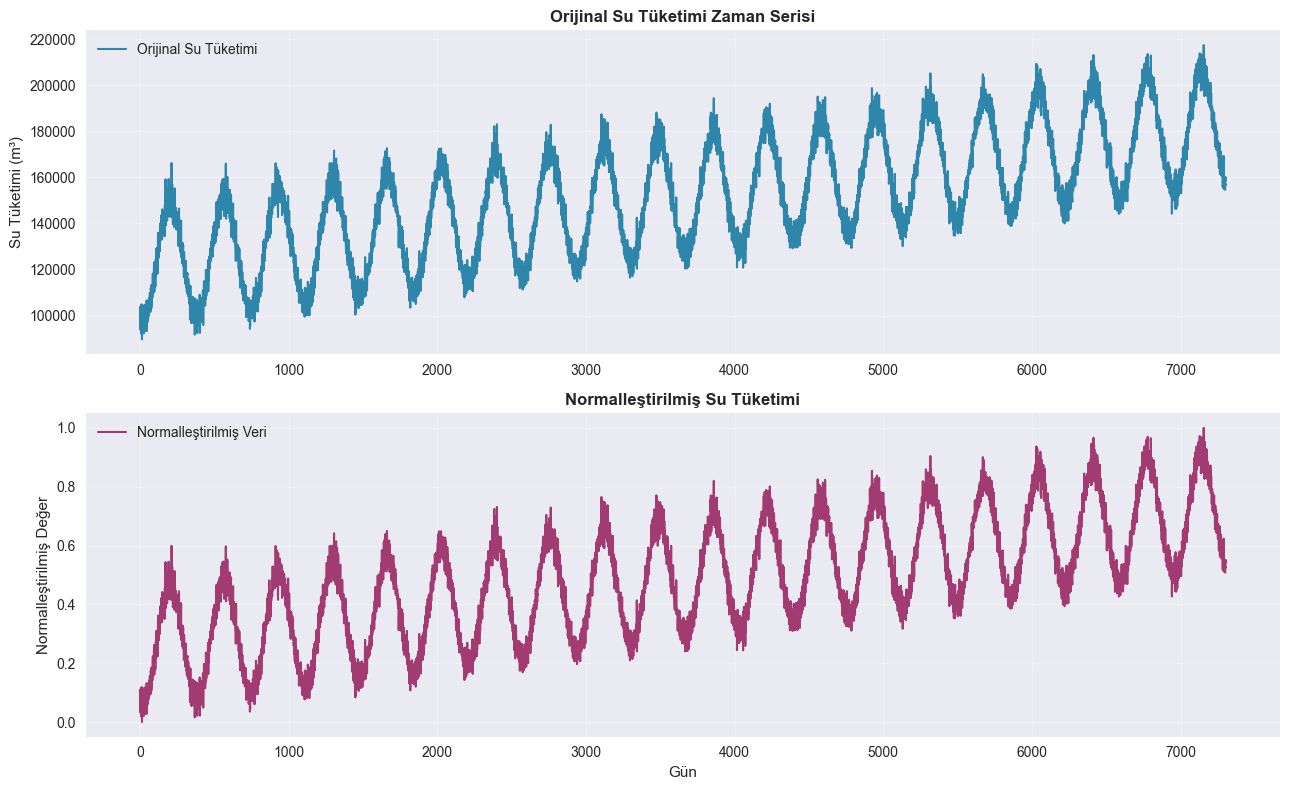


✓ Görselleştirme tamamlandı


In [4]:
# Hedef sütunu çıkar ve normalleştir
try:
    data = df_merged[[target_col]].copy()
    initial_size = len(data)
    data = data.dropna()
    removed = initial_size - len(data)
    
    if removed > 0:
        print(f"⚠️  {removed} eksik değer bulglandı ve temizlendi")
    print(f"✓ Temizlik sonrası veri: {data.shape}")
except Exception as e:
    print(f"❌ Temizleme hatası: {e}")
    raise

# MinMaxScaler kullan (LSTM için genellikle daha iyi)
try:
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data)
    print(f"✓ Veri normalleştirildi (0-1 aralığı)")
    print(f"  Min: {data_scaled.min():.4f}, Max: {data_scaled.max():.4f}")
except Exception as e:
    print(f"❌ Normalleştirme hatası: {e}")
    raise

# Görselleştir
try:
    fig, axes = plt.subplots(2, 1, figsize=(13, 8))
    
    axes[0].plot(data.values, label='Orijinal Su Tüketimi', color='#2E86AB', linewidth=1.5)
    axes[0].set_ylabel('Su Tüketimi (m³)', fontsize=11)
    axes[0].set_title('Orijinal Su Tüketimi Zaman Serisi', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(data_scaled, label='Normalleştirilmiş Veri', color='#A23B72', linewidth=1.5)
    axes[1].set_xlabel('Gün', fontsize=11)
    axes[1].set_ylabel('Normalleştirilmiş Değer', fontsize=11)
    axes[1].set_title('Normalleştirilmiş Su Tüketimi', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("\n✓ Görselleştirme tamamlandı")
except Exception as e:
    print(f"❌ Görselleştirme hatası: {e}")

## LSTM için Veri Şekillandirme

In [5]:
def create_sequences(data, look_back=60):
    """
    Zaman serisi verilerinden LSTM için sequence'lar oluştur
    
    Parametreler:
    - data: Normalleştirilmiş veri
    - look_back: Kaç gün geriye bakılacağı
    
    Çıktı:
    - X: Giriş sequence'i (gözlemler, zaman adımları, özellikler)
    - y: Hedef değeri
    """
    X, y = [], []
    
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])
        y.append(data[i + look_back])
    
    return np.array(X), np.array(y)

# Sequence'ları oluştur
look_back = 60  # Son 60 günü baz al
print(f"Lookback periyodu: {look_back} gün\n")

try:
    X, y = create_sequences(data_scaled, look_back=look_back)
    print(f"✓ Giriş verisi (X) şekli: {X.shape}")
    print(f"  - Gözlem sayısı: {X.shape[0]}")
    print(f"  - Zaman adımları: {X.shape[1]}")
    print(f"  - Özellik sayısı: {X.shape[2]}")
    print(f"\n✓ Hedef verisi (y) şekli: {y.shape}")
except Exception as e:
    print(f"❌ Sequence oluşturma hatası: {e}")
    raise

# Train-test ayırma (80-20)
try:
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    print(f"\n✓ Eğitim seti: X_train {X_train.shape}, y_train {y_train.shape}")
    print(f"✓ Test seti: X_test {X_test.shape}, y_test {y_test.shape}")
except Exception as e:
    print(f"❌ Veri ayırma hatası: {e}")
    raise

Lookback periyodu: 60 gün

✓ Giriş verisi (X) şekli: (7245, 60, 1)
  - Gözlem sayısı: 7245
  - Zaman adımları: 60
  - Özellik sayısı: 1

✓ Hedef verisi (y) şekli: (7245, 1)

✓ Eğitim seti: X_train (5796, 60, 1), y_train (5796, 1)
✓ Test seti: X_test (1449, 60, 1), y_test (1449, 1)


## LSTM Modelini Oluşturma

In [6]:
# LSTM modelini oluştur
try:
    model = Sequential([
        LSTM(50, activation='relu', return_sequences=True, input_shape=(look_back, 1)),
        Dropout(0.2),
        
        LSTM(50, activation='relu', return_sequences=True),
        Dropout(0.2),
        
        LSTM(25, activation='relu'),
        Dropout(0.2),
        
        Dense(25, activation='relu'),
        Dense(1)
    ])
    
    print("✓ LSTM modeli oluşturuldu")
    print("\nModel Mimarisi:")
    model.summary()
except Exception as e:
    print(f"❌ Model oluşturma hatası: {e}")
    raise

# Modeli derle
try:
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    print("\n✓ Model derlendi")
    print("  - Optimizer: Adam (learning_rate=0.001)")
    print("  - Loss: Mean Squared Error (MSE)")
    print("  - Metrik: Mean Absolute Error (MAE)")
except Exception as e:
    print(f"❌ Derleme hatası: {e}")
    raise

✓ LSTM modeli oluşturuldu

Model Mimarisi:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,876 (151.86 KB)

 Trainable params: 38,876 (151.86 KB)

 Non-trainable params: 0 (0.00 B)


✓ Model derlendi
  - Optimizer: Adam (learning_rate=0.001)
  - Loss: Mean Squared Error (MSE)
  - Metrik: Mean Absolute Error (MAE)


## Modeli Eğitme

In [7]:
# Callback'ları tanımla
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

# Modeli eğit
print("Model eğitimi başladı...\n")

try:
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    print("\n✓ Model eğitimi tamamlandı")
except Exception as e:
    print(f"❌ Eğitim hatası: {e}")
    raise

Model eğitimi başladı...

Epoch 1/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.0188 - mae: 0.0927 - val_loss: 0.0034 - val_mae: 0.0468 - learning_rate: 0.0010
Epoch 2/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.0032 - mae: 0.0442 - val_loss: 0.0049 - val_mae: 0.0596 - learning_rate: 0.0010
Epoch 3/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0024 - mae: 0.0380 - val_loss: 0.0064 - val_mae: 0.0680 - learning_rate: 0.0010
Epoch 4/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0020 - mae: 0.0351 - val_loss: 0.0137 - val_mae: 0.1039 - learning_rate: 0.0010
Epoch 5/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0019 - mae: 0.0337 - val_loss: 0.0127 - val_mae: 0.0988 - learning_rate: 0.0010
Epoch 6/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0019 - mae: 0.0336 - val_loss: 0.0066 - val_mae: 0.0695 - learning_rate: 0.0010
Epoch 7/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0016 - mae: 0.0315 - val_loss: 0.0051 - val_ma

## Eğitim Geçmişini Görselleştirme

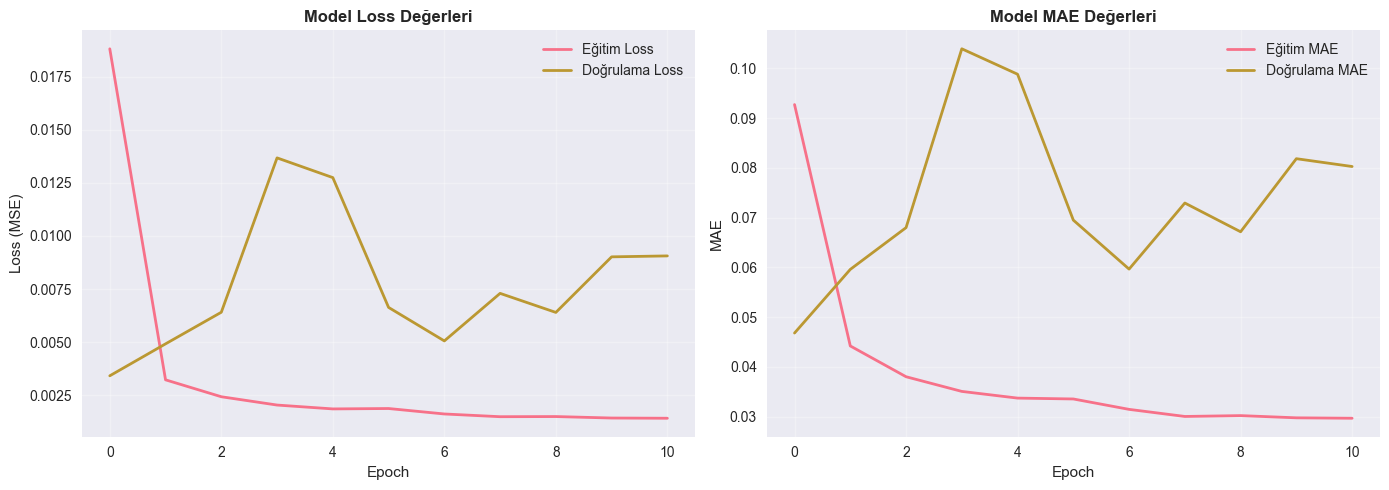

✓ Eğitim geçmişi görselleştirildi


In [8]:
# Eğitim geçmişini görselleştir
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss değeri
    axes[0].plot(history.history['loss'], label='Eğitim Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Doğrulama Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Loss (MSE)', fontsize=11)
    axes[0].set_title('Model Loss Değerleri', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # MAE değeri
    axes[1].plot(history.history['mae'], label='Eğitim MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Doğrulama MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('MAE', fontsize=11)
    axes[1].set_title('Model MAE Değerleri', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Eğitim geçmişi görselleştirildi")
except Exception as e:
    print(f"❌ Görselleştirme hatası: {e}")

## Test Verisi Üzerinde Tahmin ve Değerlendirme

In [9]:
# Test verisi üzerinde tahmin yap
try:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print(f"✓ Tahminler yapıldı")
    print(f"  - Eğitim tahmini şekli: {y_train_pred.shape}")
    print(f"  - Test tahmini şekli: {y_test_pred.shape}")
except Exception as e:
    print(f"❌ Tahmin hatası: {e}")
    raise

# Normalleştirmeleri geri al
try:
    y_train_original = scaler.inverse_transform(y_train)
    y_train_pred_original = scaler.inverse_transform(y_train_pred)
    
    y_test_original = scaler.inverse_transform(y_test)
    y_test_pred_original = scaler.inverse_transform(y_test_pred)
    
    print("✓ Normalleştirmeler geri alındı")
except Exception as e:
    print(f"❌ Ters normalleştirme hatası: {e}")
    raise

# Metrikleri hesapla
try:
    # Eğitim metrikleri
    train_mae = mean_absolute_error(y_train_original, y_train_pred_original)
    train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
    train_r2 = r2_score(y_train_original, y_train_pred_original)
    train_mape = mean_absolute_percentage_error(y_train_original, y_train_pred_original)
    
    # Test metrikleri
    test_mae = mean_absolute_error(y_test_original, y_test_pred_original)
    test_rmse = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    test_r2 = r2_score(y_test_original, y_test_pred_original)
    test_mape = mean_absolute_percentage_error(y_test_original, y_test_pred_original)
    
    print("\n" + "="*70)
    print("MODEL PERFORMANS METRIKLERI")
    print("="*70)
    
    print("\nEĞİTİM VERISINDE:")
    print(f"  MAE  (Ortalama Mutlak Hata): {train_mae:,.2f} m³")
    print(f"  RMSE (Kare Kök Ort. Hata): {train_rmse:,.2f} m³")
    print(f"  R²   (Açıklayıcılık):       {train_r2:.4f}")
    print(f"  MAPE (Ortalama Yüzde Hata): {train_mape:.2%}")
    
    print("\nTEST VERISINDE:")
    print(f"  MAE  (Ortalama Mutlak Hata): {test_mae:,.2f} m³")
    print(f"  RMSE (Kare Kök Ort. Hata): {test_rmse:,.2f} m³")
    print(f"  R²   (Açıklayıcılık):       {test_r2:.4f}")
    print(f"  MAPE (Ortalama Yüzde Hata): {test_mape:.2%}")
    print("="*70)
except Exception as e:
    print(f"❌ Metrik hesaplama hatası: {e}")
    raise

182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
✓ Tahminler yapıldı
  - Eğitim tahmini şekli: (5796, 1)
  - Test tahmini şekli: (1449, 1)
✓ Normalleştirmeler geri alındı

MODEL PERFORMANS METRIKLERI

EĞİTİM VERISINDE:
  MAE  (Ortalama Mutlak Hata): 5,676.00 m³
  RMSE (Kare Kök Ort. Hata): 7,089.99 m³
  R²   (Açıklayıcılık):       0.9051
  MAPE (Ortalama Yüzde Hata): 3.84%

TEST VERISINDE:
  MAE  (Ortalama Mutlak Hata): 6,226.34 m³
  RMSE (Kare Kök Ort. Hata): 7,774.50 m³
  R²   (Açıklayıcılık):       0.8350
  MAPE (Ortalama Yüzde Hata): 3.53%


## Tahminleri Görselleştirme

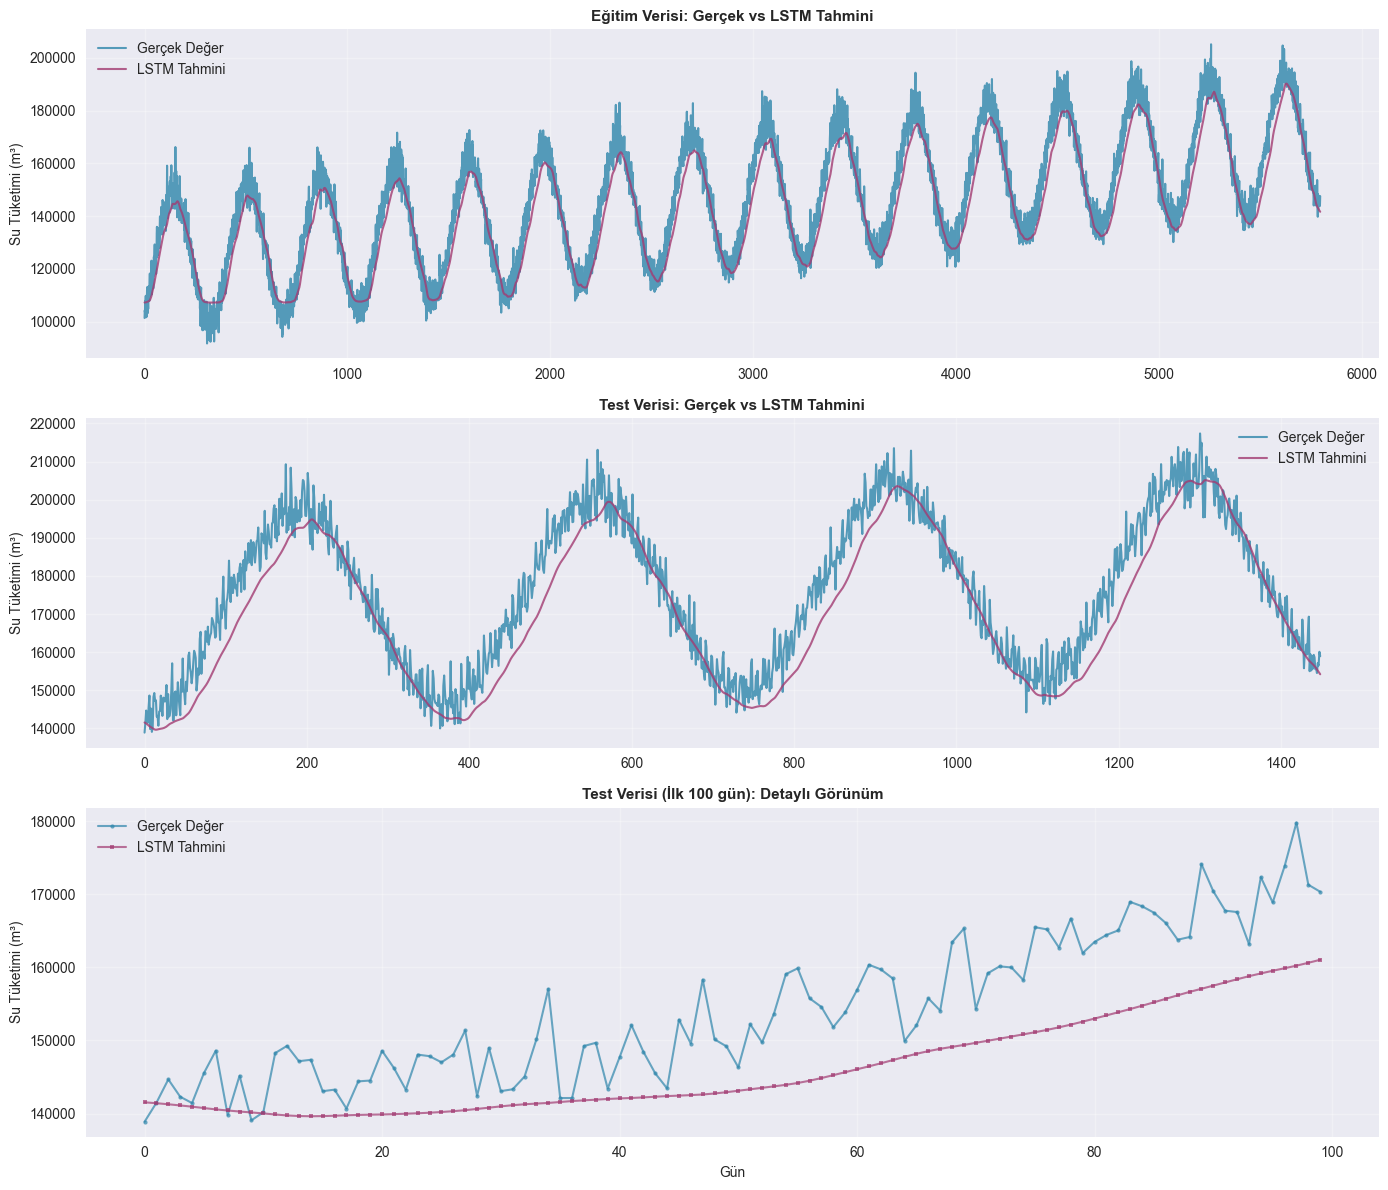

✓ Tahmin grafiği başarıyla çizildi


In [10]:
# Tahminleri gerçek değerlerle karşılaştır
try:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Eğitim verisi
    axes[0].plot(y_train_original, label='Gerçek Değer', color='#2E86AB', linewidth=1.5, alpha=0.8)
    axes[0].plot(y_train_pred_original, label='LSTM Tahmini', color='#A23B72', linewidth=1.5, alpha=0.8)
    axes[0].set_ylabel('Su Tüketimi (m³)', fontsize=10)
    axes[0].set_title('Eğitim Verisi: Gerçek vs LSTM Tahmini', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Test verisi (tam)
    axes[1].plot(y_test_original, label='Gerçek Değer', color='#2E86AB', linewidth=1.5, alpha=0.8)
    axes[1].plot(y_test_pred_original, label='LSTM Tahmini', color='#A23B72', linewidth=1.5, alpha=0.8)
    axes[1].set_ylabel('Su Tüketimi (m³)', fontsize=10)
    axes[1].set_title('Test Verisi: Gerçek vs LSTM Tahmini', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    # Test verisi (ilk 100)
    axes[2].plot(y_test_original[:100], label='Gerçek Değer', marker='o', 
                 color='#2E86AB', linewidth=1.5, markersize=3, alpha=0.7)
    axes[2].plot(y_test_pred_original[:100], label='LSTM Tahmini', marker='s', 
                 color='#A23B72', linewidth=1.5, markersize=3, alpha=0.7)
    axes[2].set_xlabel('Gün', fontsize=10)
    axes[2].set_ylabel('Su Tüketimi (m³)', fontsize=10)
    axes[2].set_title('Test Verisi (İlk 100 gün): Detaylı Görünüm', fontsize=11, fontweight='bold')
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Tahmin grafiği başarıyla çizildi")
except Exception as e:
    print(f"❌ Görselleştirme hatası: {e}")

## Residual (Hata) Analizi


Tahmin Hatası Analizi

------------------------------------------------------------
EĞİTİM VERİSİ HATALARI:
  Ortalama Hata:   3,890.09 m³
  Standart Sapma:  5,927.50 m³
  Min Hata:        -15,576.60 m³
  Max Hata:        24,132.58 m³

TEST VERİSİ HATALARI:
  Ortalama Hata:   5,039.45 m³
  Standart Sapma:  5,920.04 m³
  Min Hata:        -9,803.41 m³
  Max Hata:        22,117.27 m³
------------------------------------------------------------


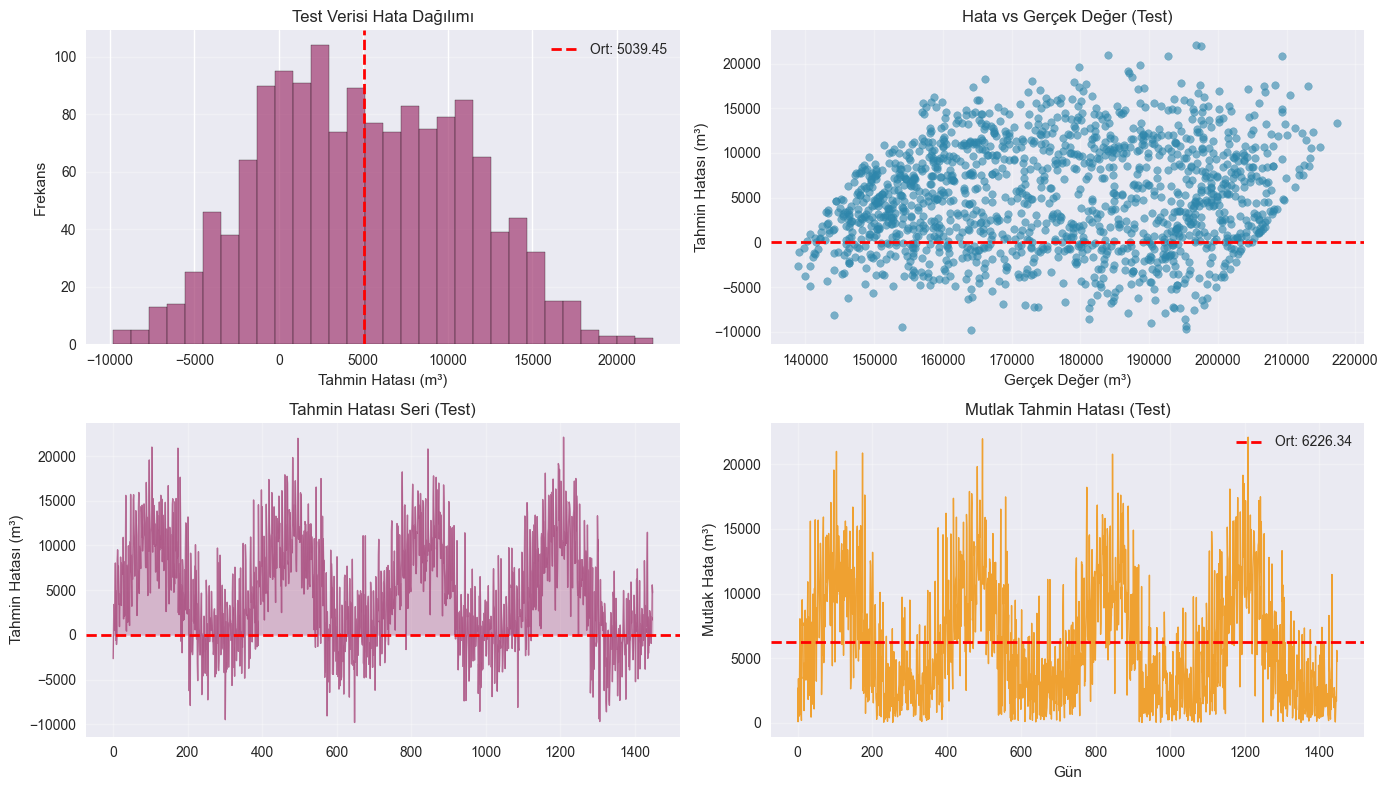


✓ Hata analizi grafikleri çizildi


In [11]:
# Hataları hesapla
try:
    train_errors = y_train_original - y_train_pred_original
    test_errors = y_test_original - y_test_pred_original
    
    print("\nTahmin Hatası Analizi\n")
    print("-" * 60)
    print("EĞİTİM VERİSİ HATALARI:")
    print(f"  Ortalama Hata:   {train_errors.mean():,.2f} m³")
    print(f"  Standart Sapma:  {train_errors.std():,.2f} m³")
    print(f"  Min Hata:        {train_errors.min():,.2f} m³")
    print(f"  Max Hata:        {train_errors.max():,.2f} m³")
    
    print("\nTEST VERİSİ HATALARI:")
    print(f"  Ortalama Hata:   {test_errors.mean():,.2f} m³")
    print(f"  Standart Sapma:  {test_errors.std():,.2f} m³")
    print(f"  Min Hata:        {test_errors.min():,.2f} m³")
    print(f"  Max Hata:        {test_errors.max():,.2f} m³")
    print("-" * 60)
except Exception as e:
    print(f"❌ Hata analizi hatası: {e}")

# Hata dağılımını görselleştir
try:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Test hata histogramı
    axes[0, 0].hist(test_errors, bins=30, color='#A23B72', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(test_errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Ort: {test_errors.mean():.2f}')
    axes[0, 0].set_xlabel('Tahmin Hatası (m³)')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].set_title('Test Verisi Hata Dağılımı')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # İçsel grafik (Q-Q plot benzeri)
    axes[0, 1].scatter(y_test_original, test_errors, alpha=0.6, color='#2E86AB', s=30)
    axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('Gerçek Değer (m³)')
    axes[0, 1].set_ylabel('Tahmin Hatası (m³)')
    axes[0, 1].set_title('Hata vs Gerçek Değer (Test)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Seri hata grafiği (test)
    axes[1, 0].plot(test_errors, color='#A23B72', linewidth=1, alpha=0.7)
    axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].fill_between(range(len(test_errors)), test_errors.flatten(), alpha=0.3, color='#A23B72')
    axes[1, 0].set_ylabel('Tahmin Hatası (m³)')
    axes[1, 0].set_title('Tahmin Hatası Seri (Test)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Mutlak hata grafiği
    abs_test_errors = np.abs(test_errors)
    axes[1, 1].plot(abs_test_errors, color='#F18F01', linewidth=1, alpha=0.8)
    axes[1, 1].axhline(y=abs_test_errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Ort: {abs_test_errors.mean():.2f}')
    axes[1, 1].set_xlabel('Gün')
    axes[1, 1].set_ylabel('Mutlak Hata (m³)')
    axes[1, 1].set_title('Mutlak Tahmin Hatası (Test)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Hata analizi grafikleri çizildi")
except Exception as e:
    print(f"❌ Görselleştirme hatası: {e}")

## Gelecek Dönem Tahmini

In [12]:
# Gelecek 30 günü tahmin et
try:
    future_days = 30
    
    # Son 60 günü sequnce olarak al
    current_sequence = data_scaled[-look_back:].reshape(1, look_back, 1)
    future_predictions_scaled = []
    
    for _ in range(future_days):
        # Bir sonraki günü tahmin et
        next_pred = model.predict(current_sequence, verbose=0)
        future_predictions_scaled.append(next_pred[0, 0])
        
        # Sequence'ı güncelle (son tahmin ekle, ilk değeri çıkar)
        current_sequence = np.append(current_sequence[0, 1:], [[next_pred[0, 0]]], axis=0)
        current_sequence = current_sequence.reshape(1, look_back, 1)
    
    # Normalleştirmeleri geri al
    future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))
    
    print(f"✓ {future_days} gün sonrasına tahmin yapıldı")
    print(f"\n30 Gün Sonrası Su Tüketim Tahminleri:")
    print("-" * 50)
    
    forecast_df = pd.DataFrame({
        'Gün': range(1, future_days + 1),
        'Tahmini Su Tüketimi (m³)': future_predictions.flatten()
    })
    
    print(forecast_df.to_string(index=False))
    print("-" * 50)
    print(f"\nTahmin Özeti:")
    print(f"  Ortalama: {future_predictions.mean():,.2f} m³")
    print(f"  Min:      {future_predictions.min():,.2f} m³")
    print(f"  Max:      {future_predictions.max():,.2f} m³")
except Exception as e:
    print(f"❌ Gelecek tahmin hatası: {e}")
    raise

✓ 30 gün sonrasına tahmin yapıldı

30 Gün Sonrası Su Tüketim Tahminleri:
--------------------------------------------------
 Gün  Tahmini Su Tüketimi (m³)
   1             153920.156250
   2             153662.781250
   3             153406.937500
   4             153143.703125
   5             152867.703125
   6             152576.203125
   7             152268.437500
   8             151945.250000
   9             151608.343750
  10             151259.750000
  11             150901.781250
  12             150536.609375
  13             150166.171875
  14             149792.187500
  15             149416.046875
  16             149039.218750
  17             148662.609375
  18             148287.046875
  19             147912.671875
  20             147539.968750
  21             147169.140625
  22             146800.234375
  23             146433.656250
  24             146069.343750
  25             145707.296875
  26             145347.671875
  27             144990.218750
  28    

## Son Veriler ile Gelecek Tahmini Görselleştirme

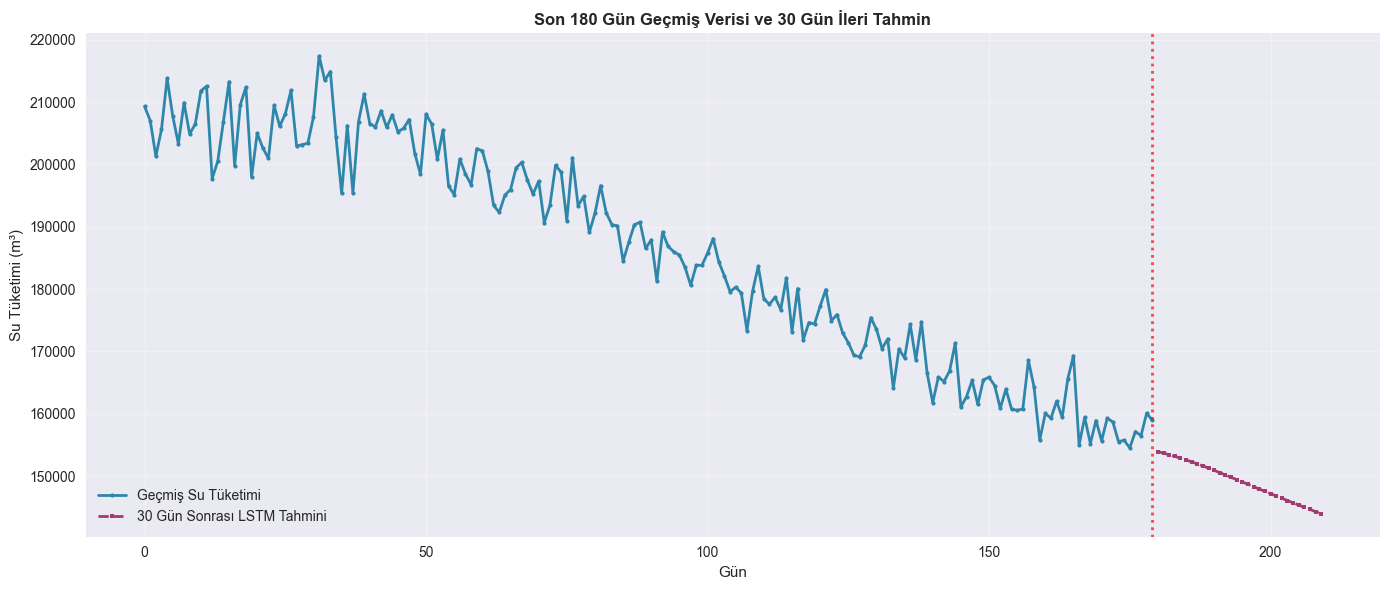

✓ Gelecek tahmin grafiği çizildi


In [13]:
# Gelecek tahmini görselleştir
try:
    # Son 180 günü ve gelecek tahmini çiz
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Son verileri al
    last_180_days = y_test_original[-180:] if len(y_test_original) >= 180 else y_test_original
    
    # X eksenini ayarla
    historical_x = range(len(last_180_days))
    future_x = range(len(last_180_days), len(last_180_days) + future_days)
    
    # Grafik
    ax.plot(historical_x, last_180_days, label='Geçmiş Su Tüketimi', color='#2E86AB', linewidth=2, marker='o', markersize=3)
    ax.plot(future_x, future_predictions, label=f'{future_days} Gün Sonrası LSTM Tahmini', 
            color='#A23B72', linewidth=2, marker='s', markersize=3, linestyle='--')
    
    # Geçmiş ve gelecek arasına çizgi çek
    ax.axvline(x=len(last_180_days)-1, color='red', linestyle=':', linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Gün', fontsize=11)
    ax.set_ylabel('Su Tüketimi (m³)', fontsize=11)
    ax.set_title('Son 180 Gün Geçmiş Verisi ve 30 Gün İleri Tahmin', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Gelecek tahmin grafiği çizildi")
except Exception as e:
    print(f"❌ Görselleştirme hatası: {e}")

## Modeli Kaydetme

In [14]:
# Modeli ve scaler'ı kaydet
try:
    model.save('lstm_su_tahmin_modeli.h5')
    print("✓ LSTM modeli kaydedildi: lstm_su_tahmin_modeli.h5")
except Exception as e:
    print(f"❌ Model kaydetme hatası: {e}")

try:
    joblib.dump(scaler, 'lstm_scaler.joblib')
    print("✓ Scaler kaydedildi: lstm_scaler.joblib")
except Exception as e:
    print(f"❌ Scaler kaydetme hatası: {e}")

try:
    # Model bilgilerini kaydet
    model_info = {
        'look_back': look_back,
        'tr_test_split': 0.8,
        'train_mae': float(train_mae),
        'test_mae': float(test_mae),
        'train_rmse': float(train_rmse),
        'test_rmse': float(test_rmse),
        'train_r2': float(train_r2),
        'test_r2': float(test_r2)
    }
    joblib.dump(model_info, 'lstm_model_info.joblib')
    print("✓ Model bilgileri kaydedildi: lstm_model_info.joblib")
except Exception as e:
    print(f"❌ Model bilgileri kaydetme hatası: {e}")

print("\n✓ Tüm dosyalar başarıyla kaydedildi!")

✓ LSTM modeli kaydedildi: lstm_su_tahmin_modeli.h5
✓ Scaler kaydedildi: lstm_scaler.joblib
✓ Model bilgileri kaydedildi: lstm_model_info.joblib

✓ Tüm dosyalar başarıyla kaydedildi!


## Özet ve Sonuçlar

In [15]:
print("\n" + "="*70)
print("LSTM MODELİ - GENEL ÖZET")
print("="*70)

print("\n📊 MODEL MİMARİSİ:")
print(f"  - Lookback Periyodu: {look_back} gün")
print(f"  - LSTM Katmanları: 3 (50-50-25 nöron)")
print(f"  - Dropout Oranı: 0.2")
print(f"  - Optimizer: Adam (learning_rate=0.001)")
print(f"  - Aktivasyon: ReLU")

print("\n📈 EĞİTİM SONUÇLARI:")
print(f"  - Toplam Epoch: {len(history.history['loss'])}")
print(f"  - Son Epoch Loss: {history.history['loss'][-1]:.6f}")
print(f"  - En Düşük Val Loss: {min(history.history['val_loss']):.6f}")

print("\n🎯 TEST PERFORMANSI:")
print(f"  - MAE:  {test_mae:,.2f} m³")
print(f"  - RMSE: {test_rmse:,.2f} m³")
print(f"  - R²:   {test_r2:.4f}")
print(f"  - MAPE: {test_mape:.2%}")

print("\n🔮 GELECEK TAHMINI ({} Gün):".format(future_days))
print(f"  - Ortalama Tahmin: {future_predictions.mean():,.2f} m³")
print(f"  - Min Tahmin:      {future_predictions.min():,.2f} m³")
print(f"  - Max Tahmin:      {future_predictions.max():,.2f} m³")

print("\n💾 KAYDEDILEN DOSYALAR:")
print("  - lstm_su_tahmin_modeli.h5")
print("  - lstm_scaler.joblib")
print("  - lstm_model_info.joblib")

print("\n" + "="*70)


LSTM MODELİ - GENEL ÖZET

📊 MODEL MİMARİSİ:
  - Lookback Periyodu: 60 gün
  - LSTM Katmanları: 3 (50-50-25 nöron)
  - Dropout Oranı: 0.2
  - Optimizer: Adam (learning_rate=0.001)
  - Aktivasyon: ReLU

📈 EĞİTİM SONUÇLARI:
  - Toplam Epoch: 11
  - Son Epoch Loss: 0.001421
  - En Düşük Val Loss: 0.003419

🎯 TEST PERFORMANSI:
  - MAE:  6,226.34 m³
  - RMSE: 7,774.50 m³
  - R²:   0.8350
  - MAPE: 3.53%

🔮 GELECEK TAHMINI (30 Gün):
  - Ortalama Tahmin: 149,142.59 m³
  - Min Tahmin:      143,929.81 m³
  - Max Tahmin:      153,920.16 m³

💾 KAYDEDILEN DOSYALAR:
  - lstm_su_tahmin_modeli.h5
  - lstm_scaler.joblib
  - lstm_model_info.joblib

